# Climate Finance EDA

In [1]:
# 1
# ── Standard library & third-party imports ──────────────────────────────────
# pandas  : tabular data manipulation (DataFrames)
# numpy   : numerical operations and NaN handling
# matplotlib.pyplot : plotting
# re      : regular-expression parsing (used to decode damage strings like "10K", "2M")
# os      : file-system utilities (mostly used for quick directory listings)
# pathlib : cross-platform path construction – safer than string concatenation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from pathlib import Path

In [2]:
# 2
# ── Define directory paths ───────────────────────────────────────────────────
# Using pathlib so the code works on Windows, macOS, and Linux without changes.
# path_data            : root data folder
# path_disaster        : raw NOAA/SHELDUS disaster data (Stata .dta file)
# path_finance         : raw Zillow / CFPB delinquency CSVs (not yet loaded here)
# path_disaster_processed : output folder for any cleaned disaster files we write
path_data = Path("./data")

path_disaster = path_data / "1-Disaster"
path_finance = path_data / "2-Finance"

path_disaster_processed = path_data / "1-Disaster_processed"

# print(os.listdir(path_data))

# wd_disaster = path_disaster

# wd_finance="/Users/jsjaramillo/Desktop/1-Climate Finance Project/Data/2-Finance/"

In [3]:
# 3
# ── Load raw data ────────────────────────────────────────────────────────────
# Disaster dataset: stored as a Stata .dta file; pd.read_stata preserves
# value labels and metadata from the original Stata workflow.
# We print shape immediately to get a quick sanity check on row / column counts.
#
# Financial datasets (delinquency rates) are commented out here because they
# will be loaded and cleaned in a later section.

#disaster data
disaster_data = pd.read_stata(path_disaster / "Disaster_Dataset_Cleaned.dta")
print(disaster_data.shape)  # (339457, 57)
print(disaster_data.head())

disaster_data.to_csv(path_disaster / "Disaster_Dataset_Cleaned.csv", na_rep="NA", index=False)

#Financial data
fin=pd.read_csv(path_finance / "Early_30_89Days_Deliquency.csv")
fin_2=pd.read_csv(path_finance / "Late_90plus_Deliquency.csv")
# print(financial_data.shape)
#financial_data.head()

(339457, 57)
   FIPS_ST STATENAME  FIPS_COUNTY COUNTYNAME  fips       time   day    month  \
0        1   ALABAMA            1    AUTAUGA  1001 1982-01-01   3.0  January   
1        1   ALABAMA            1    AUTAUGA  1001 1982-01-01   3.0  January   
2        1   ALABAMA            1    AUTAUGA  1001 1982-04-01  26.0    April   
3        1   ALABAMA            1    AUTAUGA  1001 1985-01-01  31.0  January   
4        1   ALABAMA            1    AUTAUGA  1001 1995-03-01   7.0    March   

   year  event_id  ... end_azimuth end_location  begin_lat  begin_lon  \
0  1982   9977393  ...                           32.669998 -86.519997   
1  1982   9977392  ...                           32.680000 -86.570000   
2  1982   9978548  ...                           32.549999 -86.519997   
3  1985   9975700  ...                           32.430000 -86.529999   
4  1995  10314739  ...                                 NaN        NaN   

   end_lat    end_lon episode_narrative  \
0      NaN        NaN   

In [4]:
# 4
# ── Quick structural audit of each DataFrame ────────────────────────────────
# The audit() helper prints three things for any DataFrame:
#   1. A count of each dtype (int, float, object, …) → helps spot encoding issues
#   2. The top-20 columns ranked by share of missing values → flags data-quality
#      problems early before they silently propagate through the analysis
#   3. The first 50 column names → gives a readable overview of available fields
#
# We run it on disaster_data now; the financial audit is uncommented later once
# those DataFrames are loaded.

def audit(df, name):
    print(f"\n==== {name} ====")
    print(df.dtypes.value_counts())
    print("\nTop missing columns:")
    miss = df.isna().mean().sort_values(ascending=False).head(20)
    display(miss.to_frame("missing_share"))
    print("\nColumns:")
    display(pd.Series(df.columns).to_frame("col").head(50))

audit(disaster_data, "disasters")
# audit(financial_data, "Financial")


==== disasters ====
object            27
float32            9
int16              7
float64            5
int8               4
int32              4
datetime64[ns]     1
Name: count, dtype: int64

Top missing columns:


,missing_share
category,1.000000
tor_other_cz_fips,0.993655
tor_width,0.861823
tor_length,0.861823
magnitude,0.333179
end_range,0.216896
begin_range,0.216867
end_lon,0.122852
end_lat,0.122846
begin_lon,0.104243



Columns:


,col
0,FIPS_ST
1,STATENAME
2,FIPS_COUNTY
3,COUNTYNAME
4,fips
5,time
6,day
7,month
8,year
9,event_id


In [5]:
# 5
# ── Standardise the FIPS county identifier ──────────────────────────────────
# FIPS codes are 5-digit numeric strings (e.g. "06037" for Los Angeles County).
# The raw column may contain floats (e.g. 6037.0) from Stata's numeric encoding,
# so we:
#   1. Coerce to numeric (silences errors for any non-numeric garbage → NaN)
#   2. Cast to nullable integer (Int64) so NaN is preserved, not turned into -9999
#   3. Convert back to string and zero-pad to exactly 5 characters
# After this step every non-missing FIPS looks like "06037".

# --- disasters: pick county id column ---
disaster_data["fips"] = (
    pd.to_numeric(disaster_data["fips"], errors="coerce")
      .astype("Int64")
      .astype(str)
      .str.zfill(5)
)

In [6]:
# 6
# ── Visual check after FIPS cleaning ────────────────────────────────────────
# Quickly inspect the first few rows to confirm the fips column now looks right
# (5-digit zero-padded strings) and that no other columns were accidentally changed.
disaster_data.head()

,FIPS_ST,STATENAME,FIPS_COUNTY,COUNTYNAME,fips,time,day,month,year,event_id,...,end_azimuth,end_location,begin_lat,begin_lon,end_lat,end_lon,episode_narrative,event_narrative,data_source,month_num
0,1,ALABAMA,1,AUTAUGA,01001,1982-01-01,3.0,January,1982,9977393,...,,,32.669998,-86.519997,NaN,NaN,,,PUB,1.0
1,1,ALABAMA,1,AUTAUGA,01001,1982-01-01,3.0,January,1982,9977392,...,,,32.680000,-86.570000,32.73,-86.550003,,,PUB,1.0
2,1,ALABAMA,1,AUTAUGA,01001,1982-04-01,26.0,April,1982,9978548,...,,,32.549999,-86.519997,32.57,-86.400002,,,PUB,4.0
3,1,ALABAMA,1,AUTAUGA,01001,1985-01-01,31.0,January,1985,9975700,...,,,32.430000,-86.529999,NaN,NaN,,,PUB,1.0
4,1,ALABAMA,1,AUTAUGA,01001,1995-03-01,7.0,March,1995,10314739,...,,,NaN,NaN,NaN,NaN,,Trees were downed on Interstate 65 near mile m...,CSV,3.0


In [7]:
# 7
# ── Build a first (simple) county × month exposure table ────────────────────
# Goal: for each (county, calendar-month) pair, count how many disaster events
# occurred.  This is the basic unit of analysis we will merge with loan data.
#
# Steps:
#   1. Parse the "time" column → proper datetime, then truncate to month
#      (dt.to_period("M").dt.to_timestamp() gives the first day of each month,
#       which makes merging with financial data straightforward)
#   2. Group by (fips, month) and count event_id rows → n_events
#   3. Create a binary indicator disaster_any = 1 if n_events > 0
#
# Note: This is a preliminary version; a richer version with damage totals is
# built in the cell below after we parse the damage columns.

#Let's build the county-month exposure table:

disaster_data["month"] = pd.to_datetime(disaster_data["time"], errors="coerce").dt.to_period("M").dt.to_timestamp()

dis_cm = (disaster_data
          .groupby(["fips","month"])
          .agg(n_events=("event_id","count"))
          .reset_index())

dis_cm["disaster_any"] = (dis_cm["n_events"] > 0).astype(int)
dis_cm.head()

,fips,month,n_events,disaster_any
0,01001,1982-01-01,2,1
1,01001,1982-04-01,1,1
2,01001,1985-01-01,1,1
3,01001,1995-03-01,1,1
4,01001,1995-04-01,1,1


In [8]:
# 8
# ── Coverage diagnostics for the disaster panel ─────────────────────────────
# Before trusting any results we want to know:
#   • How many unique counties appear? (breadth of geographic coverage)
#   • How many unique months appear?   (temporal span of the data)
#   • What share of key fields is missing? Missing fips or time stamps would
#     silently drop observations from every downstream merge.
#
# The missingness check focuses on the columns we actually use later:
# fips, month, event_id, event_type, and the two damage fields.

# how many unique counties and months?
n_counties = disaster_data["fips"].nunique(dropna=True)
n_months = disaster_data["month"].nunique(dropna=True)
print("unique counties:", n_counties, "| unique months:", n_months)

# missingness in key columns
key_cols = ["fips","month"]
key_cols += [c for c in ["event_id","event_type","damage_property","damage_crops"] if c in disaster_data.columns]
miss = disaster_data[key_cols].isna().mean().sort_values(ascending=False)
miss

unique counties: 3114 | unique months: 539


fips               0.0
month              0.0
event_id           0.0
event_type         0.0
damage_property    0.0
damage_crops       0.0
dtype: float64

In [9]:
# 9
# ── Parse human-readable damage strings → numeric USD values ────────────────
# Raw damage values are stored as strings like "10K", "2.5M", "1B" or plain
# numbers.  parse_damage() uses a regex to split the numeric part from the
# suffix and applies the corresponding multiplier:
#   K → ×1,000   M → ×1,000,000   B → ×1,000,000,000   (no suffix) → ×1
#
# Anything that doesn't match the pattern (e.g. "N/A", free-text descriptions)
# is returned as NaN so it doesn't corrupt aggregations later.
#
# We apply the parser to both damage_property and damage_crops and then print
# distributional summaries with tail percentiles (90th, 95th, 99th) because
# damage distributions are extremely right-skewed – the mean alone is misleading.

#Let's summarize the damage, we need to convert the data into numbers
def parse_damage(x):
    if pd.isna(x): 
        return np.nan
    s = str(x).strip().upper()
    m = re.match(r"^([0-9]*\.?[0-9]+)\s*([KMB])?$", s)
    if not m:
        return np.nan
    val = float(m.group(1))
    suf = m.group(2)
    mult = {"K":1e3, "M":1e6, "B":1e9, None:1.0}[suf]
    return val * mult

for col in ["damage_property","damage_crops"]:
    if col in disaster_data.columns:
        disaster_data[col+"_usd"] = disaster_data[col].map(parse_damage)

# quick summary
for col in ["damage_property_usd","damage_crops_usd"]:
    if col in disaster_data.columns:
        print("\n", col)
        display(disaster_data[col].describe(percentiles=[.5,.9,.95,.99]))


 damage_property_usd


count    3.394410e+05
mean     6.658446e+05
std      3.447900e+07
min      0.000000e+00
50%      6.000000e+03
90%      1.250000e+05
95%      5.000000e+05
99%      5.000000e+06
max      1.000000e+10
Name: damage_property_usd, dtype: float64


 damage_crops_usd


count    2.267660e+05
mean     4.857598e+04
std      1.701121e+06
min      0.000000e+00
50%      0.000000e+00
90%      0.000000e+00
95%      1.000000e+04
99%      5.000000e+05
max      5.000000e+08
Name: damage_crops_usd, dtype: float64

In [10]:
# 10
# ── Final county × month exposure table (with damage totals) ─────────────────
# This supersedes the simple version built above, adding two aggregated damage
# columns now that the raw strings have been converted to USD floats:
#   n_events    : count of distinct disaster events in that county-month
#   prop_damage : total property damage in USD (sum across all events)
#   crop_damage : total crop damage in USD
#   disaster_any: 1 if at least one event occurred, else 0
#
# The conditional dict unpacking (**{...} if col in ... else {}) makes the
# aggregation robust to datasets that might be missing one of these columns.
# dis_cm is the key intermediate object – every subsequent analysis builds on it.

#The county-month exposure table
agg_dict= {"event_id": "count"} if "event_id" in disaster_data.columns else {}
if "damage_property_usd" in disaster_data.columns: agg_dict["damage_property_usd"] = "sum"
if "damage_crops_usd" in disaster_data.columns:    agg_dict["damage_crops_usd"] = "sum"

dis_cm = (disaster_data
          .groupby(["fips","month"])
          .agg(**{
              "n_events": ("event_id","count") if "event_id" in disaster_data.columns else ("fips","size"),
              **({"prop_damage": ("damage_property_usd","sum")} if "damage_property_usd" in disaster_data.columns else {}),
              **({"crop_damage": ("damage_crops_usd","sum")} if "damage_crops_usd" in disaster_data.columns else {}),
          })
          .reset_index())

dis_cm["disaster_any"] = (dis_cm["n_events"] > 0).astype(int)

dis_cm.head(), dis_cm.shape

(    fips      month  n_events  prop_damage  crop_damage  disaster_any
 0  01001 1982-01-01         2     252500.0          0.0             1
 1  01001 1982-04-01         1     250000.0          0.0             1
 2  01001 1985-01-01         1         30.0          0.0             1
 3  01001 1995-03-01         1       2000.0          0.0             1
 4  01001 1995-04-01         1      35000.0          0.0             1,
 (166643, 6))

In [11]:
# 11
# ── Time-series and geographic summaries of disaster exposure ────────────────
# Two quick descriptive checks:
#   1. events_over_time : total events nationwide per month → reveals seasonality
#      (e.g. hurricane season spikes) and whether the panel has a clean start/end
#   2. top_exposed : the 20 counties with the most disaster-hit months → useful
#      later for case-study plots and for checking whether high-exposure counties
#      are plausible (coastal/tornado-alley counties)

# Events over time
events_over_time = dis_cm.groupby("month")["n_events"].sum()
display(events_over_time.head())
display(events_over_time.tail())

# Top counties by exposure months
top_exposed = dis_cm.groupby("fips")["disaster_any"].sum().sort_values(ascending=False).head(20)
top_exposed

month
1980-01-01      5
1980-02-01     10
1980-03-01     46
1980-04-01    136
1980-05-01    144
Name: n_events, dtype: int64

month
2024-10-01    156
2024-11-01    206
2024-12-01    297
2025-01-01    122
2025-02-01    313
Name: n_events, dtype: int64

fips
48201    239
28049    228
28121    225
28067    217
28075    204
28089    202
28149    195
22019    195
48439    187
28035    187
28129    182
01089    180
47157    179
28087    179
28163    177
28073    177
28085    174
47037    173
28127    173
12057    172
Name: disaster_any, dtype: int64

In [12]:
# 12
# ── Distribution of disaster event types ────────────────────────────────────
# value_counts() on event_type shows which hazard categories dominate the data
# (floods, tornadoes, hurricanes, winter storms, …).  This is important for
# later sub-group analyses – if one type overwhelmingly drives the signal we may
# want to run separate regressions or include event-type fixed effects.
disaster_data["event_type"].value_counts().head(25)

event_type
Thunderstorm        210896
Flash Flood          37348
Tornado              31084
Hail                 30910
Flood                14312
Lightning            12458
Heavy Rain            1300
Debris Flow            427
Wildfire               342
Dust Devil             141
Storm Surge/Tide       102
Strong Wind             39
Heavy Snow              26
Coastal Flood           17
Waterspout              14
High Wind               11
Funnel Cloud            10
Winter Weather           8
Seiche                   4
High Surf                3
Rip Current              2
Tropical Storm           1
Frost/Freeze             1
Marine High Wind         1
Name: count, dtype: int64

Let's try to do the same for the financial data set, first merge both financial data.

Let's print the first 5 rows:

In [13]:
# 13
# ── Preview the raw early-delinquency financial data ────────────────────────
# fin is the 30–89 day delinquency dataset (loaded above, currently commented
# out).  Displaying 10 rows gives us a feel for the wide-format structure:
# each row is a geography (county / metro) and each column is a YYYY-MM date.
# This "wide" layout needs to be pivoted to long format before it can be merged
# with the disaster panel.
fin.head(10)

,RegionType,State,Name,FIPSCode,2008-01,2008-02,2008-03,2008-04,2008-05,2008-06,...,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
0,National,NaN,United States,-----,3.5,3.2,3.1,3.1,3.2,3.2,...,1.4,1.8,1.8,1.5,1.8,1.5,2.0,2.0,1.6,1.7
1,County,AL,Baldwin County,'01003',2.8,3.1,3.2,2.5,2.7,2.7,...,1.3,1.7,2.0,1.6,1.8,1.7,1.7,1.9,1.8,1.8
2,County,AL,Jefferson County,'01073',5.1,4.6,4.5,4.9,4.9,5.0,...,2.4,2.7,2.9,2.5,3.0,2.9,3.2,2.9,2.6,2.6
3,County,AL,Lee County,'01081',3.8,4.5,4.2,3.6,3.8,4.4,...,1.6,2.0,2.3,1.3,2.1,1.6,2.7,1.8,1.0,1.6
4,County,AL,Madison County,'01089',3.5,3.3,3.3,3.0,3.3,3.2,...,1.7,1.5,1.5,1.3,1.6,1.7,1.9,1.9,1.4,1.7
5,County,AL,Mobile County,'01097',5.0,4.5,4.7,4.8,5.2,4.7,...,3.0,3.1,3.5,3.2,3.5,3.4,3.9,4.4,3.7,3.4
6,County,AL,Montgomery County,'01101',6.0,5.3,5.1,5.4,5.1,4.7,...,2.4,3.2,3.0,2.0,3.1,2.9,3.1,2.9,2.5,3.0
7,County,AL,Shelby County,'01117',3.0,3.0,3.3,2.7,2.5,3.1,...,1.6,1.9,1.9,1.4,2.0,1.8,2.0,2.3,1.7,2.0
8,County,AL,Tuscaloosa County,'01125',3.9,3.2,3.2,3.5,4.5,4.1,...,2.6,3.4,3.5,2.9,3.5,2.5,4.0,4.1,3.6,3.7
9,County,AK,Anchorage Municipality,'02020',2.8,2.5,2.5,2.5,2.4,2.4,...,0.9,1.4,1.5,1.3,1.4,1.0,1.2,1.6,1.3,1.3


We see we need to clear the fips column

In [14]:
# 14
# ── Clean FIPS codes in the financial data ───────────────────────────────────
# The FIPSCode column in the Zillow/CFPB files often contains stray characters:
# dashes ("-----"), decimal points ("6037.0"), quotes, or leading spaces.
# clean_fips() normalises them to the same 5-digit zero-padded string format
# used in the disaster panel so that the two datasets can be merged on ["fips"].
#
# Steps inside clean_fips():
#   1. Convert everything to string
#   2. Replace known placeholder strings with NaN
#   3. Strip all non-digit characters (handles "6,037", "6037.0", etc.)
#   4. Replace now-empty strings with NaN
#   5. Left-pad with zeros to exactly 5 digits
#
# We apply the function to both financial files and then drop rows where fips
# could not be recovered, since those observations cannot be matched to counties.
#
# ── Reshape financial data from wide to long ─────────────────────────────────
# wide_to_long() detects month columns by their YYYY-MM format (length 7,
# dash at position 4) and uses pd.melt() to pivot the wide table into a long
# one with columns: [RegionType, State, Name, fips, ym, value].
#   • ym  : parsed as a proper datetime for easy date arithmetic
#   • value: coerced to numeric (non-numeric entries → NaN)
#
# We apply this reshape to both delinquency files, then merge them on [fips, ym]
# using a LEFT join on fin1 so that every early-delinquency observation is
# retained even if the 90+ counterpart is missing (left join preserves coverage).

def clean_fips(series: pd.Series) -> pd.Series:
    s = series.astype(str)

    # Convert obvious missing placeholders to NaN
    s = s.replace(["-----", "nan", "None", ""], np.nan)

    # Keep digits only (removes quotes, decimals, spaces, etc.)
    s = s.str.replace(r"[^0-9]", "", regex=True)

    # Empty -> NaN
    s = s.replace("", np.nan)

    # Pad to 5 digits
    s = s.str.zfill(5)

    return s

# Financial file
fin["fips"] = clean_fips(fin["FIPSCode"])
fin_2["fips"] = clean_fips(fin_2["FIPSCode"])

# Drop rows with missing/invalid fips (optional but usually correct)
fin = fin.dropna(subset=["fips"])
fin_2 = fin_2.dropna(subset=["fips"])


#First we convert the data frame as a time series object, there are 207 months 
def wide_to_long(fin_df: pd.DataFrame, metric_name: str) -> pd.DataFrame:
    # Identify month columns: strings of length 7 with a dash at index 4 (YYYY-MM)
    month_cols = [c for c in fin_df.columns if isinstance(c, str) and len(c) == 7 and c[4] == "-"]

    # Melt from wide (one column per month) to long (one row per county-month)
    out = fin_df.melt(
        id_vars=["RegionType", "State", "Name", "fips"],
        value_vars=month_cols,
        var_name="ym",
        value_name="value"
    )

    # Parse the year-month string into a proper datetime
    out["ym"] = pd.to_datetime(out["ym"], format="%Y-%m")
    # Force delinquency rates to numeric; non-numeric entries become NaN
    out["value"] = pd.to_numeric(out["value"], errors="coerce")

    #Need to merge the two financial data sets 
    #out["metric"] = metric_name


    return out

fin1_long = wide_to_long(fin, "fin_metric_1")
fin2_long = wide_to_long(fin_2, "fin_metric_2")

# Left-join 90+ delinquency onto early delinquency on county × month
fin_merged = fin1_long.merge(fin2_long, on=["fips","ym"], how="left", suffixes=("_1","_2"))


fin_merged.head()

,RegionType_1,State_1,Name_1,fips,ym,value_1,RegionType_2,State_2,Name_2,value_2
0,County,AL,Baldwin County,01003,2008-01-01,2.8,County,AL,Baldwin County,1.3
1,County,AL,Jefferson County,01073,2008-01-01,5.1,County,AL,Jefferson County,2.1
2,County,AL,Lee County,01081,2008-01-01,3.8,County,AL,Lee County,1.4
3,County,AL,Madison County,01089,2008-01-01,3.5,County,AL,Madison County,0.8
4,County,AL,Mobile County,01097,2008-01-01,5.0,County,AL,Mobile County,1.9


In [15]:
# 15
# ── Validate the financial merge ─────────────────────────────────────────────
# Three checks:
#   1. No duplicated (fips, ym) pairs – a violation would mean multiple rows per
#      county-month, which would distort averages in every later aggregation.
#      The assert will raise an AssertionError immediately if this happens.
#   2. Print row counts for both input files and the merged output to see how
#      much coverage was lost (a left join keeps all fin1 rows, but some may
#      have no matching fin2 row, resulting in NaN for dq_90p).
#   3. Show missingness across merged columns so we know which fields are
#      unreliable before using them in regressions.

# Did we accidentally duplicate rows?
assert not fin_merged.duplicated(["fips","ym"]).any()

# Coverage loss (if inner join)
print("fin1 rows:", len(fin1_long))
print("fin2 rows:", len(fin2_long))
print("merged rows:", len(fin_merged))

# Missingness after merge (useful for left join)
miss = fin_merged.isna().mean().sort_values(ascending=False).head(20)
miss

fin1 rows: 97497
fin2 rows: 97497
merged rows: 97497


RegionType_1    0.0
State_1         0.0
Name_1          0.0
fips            0.0
ym              0.0
value_1         0.0
RegionType_2    0.0
State_2         0.0
Name_2          0.0
value_2         0.0
dtype: float64

In [16]:
# 16
# ── Rename columns and add a standardised month key ──────────────────────────
# Give the two delinquency measures human-readable names:
#   dq_30_89 : share of mortgages 30–89 days past due  (early-stage delinquency)
#   dq_90p   : share of mortgages 90+ days past due    (serious / late-stage)
#
# We also create a "month" column (first day of each month, same format as in
# dis_cm) so that the merge with the disaster panel can use a single consistent
# key.  Using dt.to_period("M").dt.to_timestamp() guarantees that any
# sub-monthly datetime offsets are truncated before the join.

fin = fin_merged.copy()

#Rename the columns
fin = fin.rename(columns={
    "value_1": "dq_30_89",
    "value_2": "dq_90p",
})

#disaster data has month as the time variable
fin["month"] = pd.to_datetime(fin["ym"], errors="coerce").dt.to_period("M").dt.to_timestamp()



We can start from this point to analyze the financial data

In [17]:
# 17
# ── National time-series of average delinquency rates ────────────────────────
# Aggregate both delinquency measures to the national monthly average.
# This gives a high-level view of the data: do the rates show expected
# patterns (e.g. spike around 2008–2010 financial crisis)?  Unexpected flat
# lines or sudden jumps would signal data quality issues we need to address
# before modelling.

#grouping by
ts = fin.groupby("ym")[["dq_30_89","dq_90p"]].mean()
ts.head(12)

,dq_30_89,dq_90p
ym,,
2008-01-01,3.442463,1.433970
2008-02-01,3.150955,1.464119
2008-03-01,2.998089,1.460297
2008-04-01,3.012102,1.433970
2008-05-01,3.161783,1.498726
2008-06-01,3.135669,1.561571
2008-07-01,3.266667,1.699151
2008-08-01,3.480892,1.759448
2008-09-01,3.532909,1.844374


In [18]:
# 18
# ── Cross-sectional snapshot at the most recent available month ───────────────
# Grab the last month in the financial panel and describe the distribution of
# both delinquency rates across all counties at that point in time.
# Useful for sanity-checking magnitudes (e.g. is the mean dq_30_89 ≈ 1–3%
# as we'd expect from public reports?) and spotting outliers.

m = fin["ym"].dropna().sort_values().iloc[-1]  # latest month available
fin.loc[fin["ym"]==m, ["dq_30_89","dq_90p"]].describe()

,dq_30_89,dq_90p
count,471.000000,471.000000
mean,1.695541,0.722293
std,0.773718,0.383034
min,0.200000,0.100000
25%,1.100000,0.500000
50%,1.600000,0.700000
75%,2.200000,0.900000
max,5.600000,2.400000


In [19]:
# 19
# ── Merge financial panel with disaster exposure ──────────────────────────────
# Join the financial data (fin) and the disaster exposure table (dis_cm)
# on [fips, month] using a LEFT join so every financial observation is kept,
# even for county-months with no recorded disaster.
#
# After the join:
#   • disaster_any is NaN for non-disaster county-months → fill with 0
#     (absence of a match = no disaster, not missing information)
#   • n_events is likewise filled with 0 for the same reason
#
# The resulting "panel" DataFrame is the main analytical object:
# one row per county × month, with both financial outcomes and disaster exposure.

#Merging the data sets
panel = fin.merge(dis_cm, on=["fips","month"], how="left")
panel["disaster_any"] = panel["disaster_any"].fillna(0).astype(int)
panel["n_events"] = panel["n_events"].fillna(0)



In [20]:
# 20
# ── Quick look at the merged panel ───────────────────────────────────────────
# Display the first few rows to confirm that the merge worked as expected:
# both delinquency columns and disaster columns should appear side-by-side.
# Check that fips and month look correct and that prop_damage / crop_damage
# columns are present if they were created in the disaster aggregation step.
panel.head()

,RegionType_1,State_1,Name_1,fips,ym,dq_30_89,RegionType_2,State_2,Name_2,dq_90p,month,n_events,prop_damage,crop_damage,disaster_any
0,County,AL,Baldwin County,01003,2008-01-01,2.8,County,AL,Baldwin County,1.3,2008-01-01,0.0,NaN,NaN,0
1,County,AL,Jefferson County,01073,2008-01-01,5.1,County,AL,Jefferson County,2.1,2008-01-01,0.0,NaN,NaN,0
2,County,AL,Lee County,01081,2008-01-01,3.8,County,AL,Lee County,1.4,2008-01-01,1.0,5000.0,0.0,1
3,County,AL,Madison County,01089,2008-01-01,3.5,County,AL,Madison County,0.8,2008-01-01,2.0,10000.0,0.0,1
4,County,AL,Mobile County,01097,2008-01-01,5.0,County,AL,Mobile County,1.9,2008-01-01,0.0,NaN,NaN,0


# My first natural question is: how quickly risk rises after an event?

Let's explore this question

In [21]:
# 21
# ── Event-study (relative-time) analysis ─────────────────────────────────────
# Goal: measure how delinquency rates evolve in the months before and after
# a county's FIRST recorded disaster, averaging across all treated counties.
#
# Steps:
#   1. Identify each county's first disaster month (the "treatment date").
#   2. Join this date back onto the full panel so every row knows its county's
#      treatment date.
#   3. Drop counties that never experienced a disaster (no treatment date).
#   4. Convert calendar months to integer indices (year×12 + month number) to
#      compute a signed "event_time" in months relative to the first disaster:
#        event_time = 0  → the disaster month itself
#        event_time = -3 → three months before
#        event_time = +6 → six months after
#   5. Restrict to a ±12-month window around the event.
#   6. Average dq_30_89 and dq_90p by event_time → the event-study means.
#
# This is a descriptive precursor to a formal difference-in-differences or
# two-way fixed-effects regression.  Flat pre-trends would support a parallel-
# trends assumption; non-flat pre-trends (as we see) suggest confounding.

# first disaster month per county (same as before)
first_event = (panel.loc[panel["disaster_any"] == 1]
               .groupby("fips")["month"].min()
               .rename("first_disaster_month"))

p2 = panel.join(first_event, on="fips").copy()
# Keep only counties that ever had a disaster (need a treatment date to anchor on)
p2 = p2[p2["first_disaster_month"].notna()].copy()

# robust month index: avoids timezone / period arithmetic edge cases
p2["m_idx"]  = p2["month"].dt.year * 12 + p2["month"].dt.month
p2["m0_idx"] = p2["first_disaster_month"].dt.year * 12 + p2["first_disaster_month"].dt.month

# Signed distance (in months) from the first disaster
p2["event_time"] = (p2["m_idx"] - p2["m0_idx"]).astype(int)

# Restrict to ±12-month window and average outcomes across counties at each lag
win = p2[p2["event_time"].between(-12, 12)]
evt = win.groupby("event_time")[["dq_30_89", "dq_90p"]].mean()
evt

,dq_30_89,dq_90p
event_time,,
-12,2.771698,2.279245
-11,2.856364,2.280000
-10,2.836667,2.261667
-9,2.901613,2.380645
-8,2.866667,2.482540
-7,3.023171,2.315854
-6,3.119091,2.091818
-5,3.237158,1.895628
-4,3.157466,1.831222


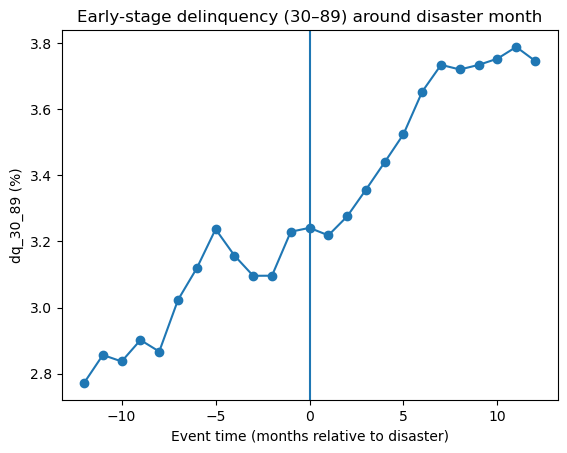

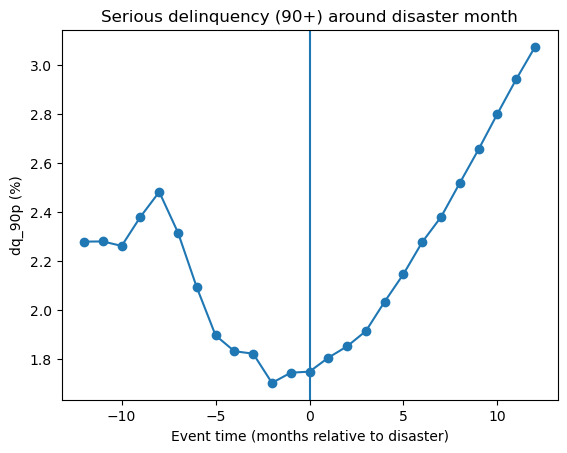

In [22]:
# 22
# ── Event-study plots ────────────────────────────────────────────────────────
# Plot the averaged delinquency rates against event_time for both metrics.
#
# The vertical line at x = 0 marks the first disaster month.
# We expect:
#   • Flat pre-trend (months < 0) if disasters are quasi-random relative to
#     credit conditions → supports a causal interpretation.
#   • A visible post-disaster uptick (months > 0) → evidence of a causal effect.
#
# Non-flat pre-trends (which we observe) indicate selection bias: counties
# that experience disasters may already have deteriorating credit conditions.
# This motivates controls, matching, or two-way fixed-effects in later work.

# --- plot dq_30_89 ---
plt.figure()
plt.plot(evt.index, evt["dq_30_89"], marker="o")
plt.axvline(0)
plt.xlabel("Event time (months relative to disaster)")
plt.ylabel("dq_30_89 (%)")
plt.title("Early-stage delinquency (30–89) around disaster month")
plt.show()

# --- plot dq_90p ---
plt.figure()
plt.plot(evt.index, evt["dq_90p"], marker="o")
plt.axvline(0)
plt.xlabel("Event time (months relative to disaster)")
plt.ylabel("dq_90p (%)")
plt.title("Serious delinquency (90+) around disaster month")
plt.show()

A couple quick read-outs from the plots:

 - dq_30_89 (early delinquency) trends upward both before and after 0, and keeps rising through +12.

 - dq_90p (serious delinquency) dips before 0 and then rises sharply after 0 through +12


**A red flag**:
 - pre-trends aren't flat, a possible explanation could be that counties experiencing disasters at different times, or disaster timing correlated with credit conditions

# Issues

- Do not trust in my merging, could be better, there are a lot of NAN, this could bias the results, need to think about how to imputate this.

- I am not considering all the columns, maybe it's a good idea to add more variables, probably we can use important features to select the best ones, or use PCA

-

# Brainstorm ideas

- Generalize this inference procedure grouped by county, maybe 10 top counties with most disasters

- There are possible confounder variables that probably we are not controlling, e.g. our estimates above could be bias, maybe try *Two-way FE*

- Recently learn about BART, I think it fits well in the problem, and bayes analysis are becoming popular